In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import (silhouette_score,accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)
from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_score)
%matplotlib inline

df = pd.read_csv(r"E:\computer science (Mostafa)\IEEE AI Task\IEEE-AI-Ambassadors-2026\Task_09\CC GENERAL.csv")
df.head(21)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


## Data Exploration 

In [37]:
df.shape

(8950, 18)

In [38]:
df.ndim

2

In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [41]:
miss = df.isnull().sum().sort_values(ascending=False)
miss_per = ((df.isnull().sum() / len(df)) * 100).round(2).sort_values(ascending=False)
pd.DataFrame({"Missing Values": miss, "Missing Percentage": miss_per})[miss > 0]

,Missing Values,Missing Percentage
MINIMUM_PAYMENTS,313,3.50
CREDIT_LIMIT,1,0.01


In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
skewness = df.skew(numeric_only=True).sort_values(ascending=False)
print(skewness)

MINIMUM_PAYMENTS                    13.622797
ONEOFF_PURCHASES                    10.045083
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
PAYMENTS                             5.907620
CASH_ADVANCE_TRX                     5.721298
CASH_ADVANCE                         5.166609
PURCHASES_TRX                        4.630655
BALANCE                              2.393386
PRC_FULL_PAYMENT                     1.942820
CASH_ADVANCE_FREQUENCY               1.828686
ONEOFF_PURCHASES_FREQUENCY           1.535613
CREDIT_LIMIT                         1.522464
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
PURCHASES_FREQUENCY                  0.060164
BALANCE_FREQUENCY                   -2.023266
TENURE                              -2.943017
dtype: float64


In [44]:
df.drop("CUST_ID", axis=1, inplace=True)


## Data Spliting and Log Transformation and  Feature Scaling  

In [45]:
X_train , X_test = train_test_split(df,random_state=42 ,train_size = 0.8)

In [46]:
class LogTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.asarray(X)
        return np.log1p(X)


In [47]:
preprocessing_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", LogTransformer()),
    ("scaler", RobustScaler())
])


In [48]:
X_train_scaled = preprocessing_pipeline.fit_transform(X_train)
X_test_scaled = preprocessing_pipeline.transform(X_test)

feature_names = X_train.columns

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=feature_names,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=feature_names,
    index=X_test.index
)

X_train_scaled.head(11)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
7055,-0.592131,-1.825002,0.101091,0.368234,0.064417,0.000000,0.297784,1.192900,0.637357,0.000000,0.000000,0.286092,-0.130059,-1.114337,-0.564355,0.000000,-0.262364
4580,0.475219,0.000000,-1.773975,-0.564715,-0.733947,0.719181,-0.710662,-0.331903,-0.275459,0.428243,0.430677,-0.946395,0.551627,-0.041439,1.068835,0.000000,0.000000
8545,-0.178436,0.000000,-1.773975,-0.564715,-0.733947,1.218881,-0.710662,-0.331903,-0.275459,3.242949,1.543959,-0.946395,-0.783504,1.065680,0.000013,4.539279,0.000000
4463,-1.264186,-3.109313,0.501905,-0.023270,0.493793,0.000000,0.429629,0.000000,0.807670,0.000000,0.000000,0.220964,-0.289225,0.473894,-1.730049,0.000000,0.000000
5705,0.510626,0.000000,-0.571592,0.064617,-0.733947,1.129256,-0.570371,0.000000,-0.275459,1.193863,1.209062,-0.630930,0.494517,0.009211,0.903654,0.000000,0.000000
4011,-0.659561,-7.003342,-0.125180,-0.564715,0.157375,0.999636,0.504223,-0.331903,0.963154,0.428243,0.682606,0.220964,-0.653517,0.227286,-0.674303,0.000000,0.000000
2906,-1.146169,0.000000,-0.003070,-0.564715,0.223387,0.000000,0.504223,-0.331903,0.847828,0.000000,0.000000,0.053605,-0.783504,-0.679739,-0.569227,3.384866,-0.367725
3971,0.307755,0.000000,0.722855,0.712686,0.327841,0.000000,0.504223,2.181494,0.346945,0.000000,0.000000,0.500000,0.604504,0.861519,0.330827,0.000000,0.000000
8038,0.138698,0.000000,-0.938748,-0.127554,-0.733947,0.000000,-0.570371,0.000000,-0.275459,0.000000,0.000000,-0.630930,-0.494398,-0.705407,0.223795,0.000000,0.000000
1329,-0.312800,-1.476794,0.184891,0.296767,0.254250,0.000000,0.351717,1.988596,0.724541,0.000000,0.000000,0.671714,0.205233,0.439995,-0.187587,0.651617,0.000000


In [49]:
skewnesss = X_train_scaled.skew()
print(skewnesss)

BALANCE                            -0.846704
BALANCE_FREQUENCY                  -2.269948
PURCHASES                          -0.763854
ONEOFF_PURCHASES                    0.195204
INSTALLMENTS_PURCHASES             -0.027532
CASH_ADVANCE                        0.263528
PURCHASES_FREQUENCY                -0.088301
ONEOFF_PURCHASES_FREQUENCY          1.299774
PURCHASES_INSTALLMENTS_FREQUENCY    0.372627
CASH_ADVANCE_FREQUENCY              1.473712
CASH_ADVANCE_TRX                    0.955151
PURCHASES_TRX                       0.036368
CREDIT_LIMIT                       -0.116365
PAYMENTS                           -1.794389
MINIMUM_PAYMENTS                    0.274511
PRC_FULL_PAYMENT                    1.740230
TENURE                             -3.174571
dtype: float64


## Kmeans

In [50]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=20)
    labels = kmeans.fit_predict(X_train_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, labels))

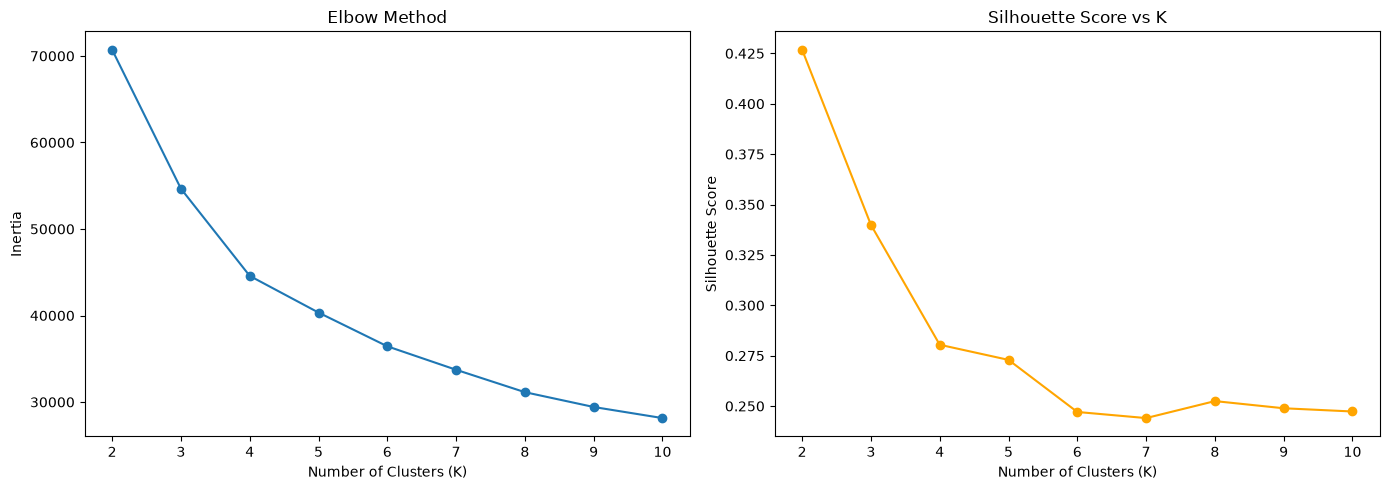

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_k = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

results_k["k"] = results_k["K"]
results_k["Silhouette"] = results_k["Silhouette Score"]

axes[0].plot(results_k["K"], results_k["Inertia"], marker="o")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(results_k["k"], results_k["Silhouette"], marker="o", color="orange")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs K")

plt.tight_layout()
plt.show()

In [52]:
best_k_by_silhouette = results_k.loc[results_k["Silhouette Score"].idxmax(),"K"]

print("Best K according to Silhouette Score:",  best_k_by_silhouette)


Best K according to Silhouette Score: 2


In [53]:
FINAL_K = int(best_k_by_silhouette)


In [54]:
kmeans_final = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=20
)

train_clusters = kmeans_final.fit_predict(X_train_scaled)
test_clusters = kmeans_final.predict(X_test_scaled)


In [55]:
print("Train cluster distribution:")
print(pd.Series(train_clusters).value_counts().sort_index())

print("\nTest cluster distribution:")
print(pd.Series(test_clusters).value_counts().sort_index())


Train cluster distribution:
0    6039
1    1121
Name: count, dtype: int64

Test cluster distribution:
0    1532
1     258
Name: count, dtype: int64


In [56]:
cluster_distribution = (
    pd.Series(train_clusters)
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_distribution


0    84.34
1    15.66
Name: proportion, dtype: float64

In [57]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(
    X_train_pca,
    columns=["PC1", "PC2"],
    index=X_train_scaled.index
)

pca_df["Cluster"] = train_clusters

pca_df.head()

,PC1,PC2,Cluster
7055,-0.864472,0.256075,0
4580,1.269604,-1.853223,0
8545,0.914344,0.739828,0
4463,-2.212502,0.487471,1
5705,1.536237,-1.591573,0


In [58]:
pca = PCA(n_components=2, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(
    X_train_pca,
    columns=["PC1", "PC2"],
    index=X_train_scaled.index
)

pca_df["Cluster"] = train_clusters

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)


Explained variance: [0.41504493 0.23344637]
Total explained variance: 0.6484912981012887


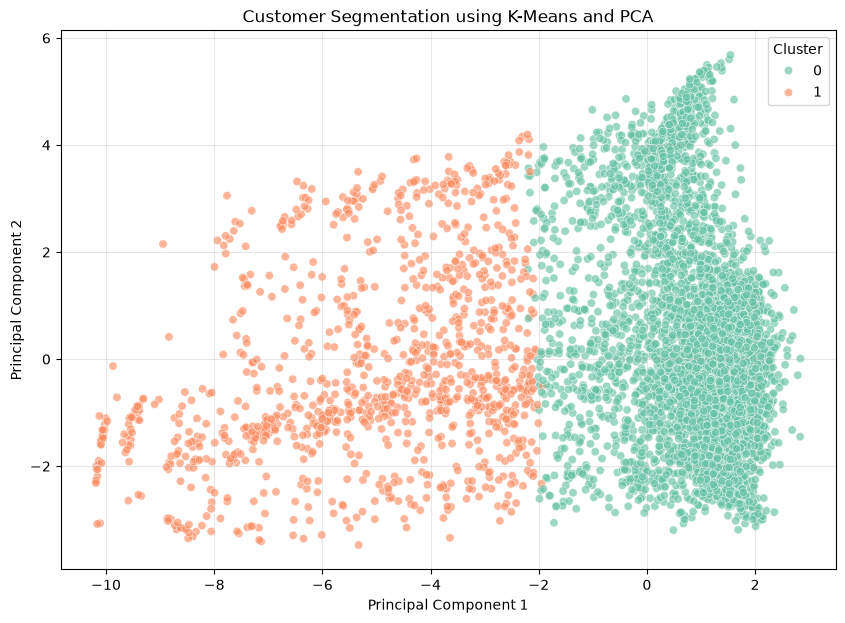

In [59]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    alpha=0.65
)

plt.title("Customer Segmentation using K-Means and PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.show()


In [60]:
X_train_profile = X_train.copy()

X_train_profile["Cluster"] = train_clusters

cluster_profile = (
    X_train_profile
    .groupby("Cluster")
    .mean()
    .round(2)
)

cluster_profile


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1839.06,0.97,1110.0,661.73,448.41,1090.56,0.52,0.22,0.39,0.15,3.71,16.38,4671.06,1827.00,978.18,0.14,11.56
1,128.59,0.38,358.9,187.90,171.43,421.15,0.30,0.07,0.22,0.04,0.97,5.01,3771.94,1218.68,153.88,0.24,11.31


In [61]:
cluster_names = { 0: "Low Activity Customers", 1: "High Activity Customers" }

In [62]:
cluster_summary = cluster_profile.copy()
cluster_summary.index = [
    cluster_names.get(i, f"Cluster {i}")
    for i in cluster_summary.index
]

cluster_summary


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Low Activity Customers,1839.06,0.97,1110.0,661.73,448.41,1090.56,0.52,0.22,0.39,0.15,3.71,16.38,4671.06,1827.00,978.18,0.14,11.56
High Activity Customers,128.59,0.38,358.9,187.90,171.43,421.15,0.30,0.07,0.22,0.04,0.97,5.01,3771.94,1218.68,153.88,0.24,11.31


In [63]:
y_train = train_clusters
y_test = test_clusters


In [64]:
X_train_supervised = X_train_scaled
X_test_supervised = X_test_scaled


In [65]:
y_train, y_test = train_clusters, test_clusters

models = {"Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
          "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
          "SVM (RBF)": SVC(kernel="rbf", random_state=42),}

rows = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)          
    fitted_models[name] = model

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    rows.append({
        "Model": name,
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Train-Test Gap": round(train_acc - test_acc, 4),
    })

results = pd.DataFrame(rows).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results

,Model,Train Accuracy,Test Accuracy,Train-Test Gap
0,Logistic Regression,0.9997,0.9994,0.0003
1,SVM (RBF),0.9986,0.9978,0.0008
2,Random Forest,1.0000,0.9972,0.0028


In [66]:
best_model_name = results.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print(f"Best model before tuning: {best_model_name}")
print("\nClassification Report test set:")
print(classification_report(y_test, best_model.predict(X_test_scaled)))

Best model before tuning: Logistic Regression

Classification Report test set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1532
           1       1.00      1.00      1.00       258

    accuracy                           1.00      1790
   macro avg       1.00      1.00      1.00      1790
weighted avg       1.00      1.00      1.00      1790



In [67]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

rf_for_tuning = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.9967877094972067


In [68]:
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test_scaled)
best_test_accuracy = accuracy_score(y_test, best_pred)


print("Tuned RF Test Accuracy:", best_test_accuracy)
print("Baseline RF Test Accuracy :",
      results.loc[results["Model"] == "Random Forest", "Test Accuracy"].values[0])

Tuned RF Test Accuracy: 0.9966480446927374
Baseline RF Test Accuracy : 0.9972
